In [12]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
# Loading the dataset and reading it into a pandas DataFrame
df = pd.read_csv('data_jobs.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [14]:
# Filtering the DataFrame to include only rows where the 'job_country' is 'India' and dropping rows with missing values in the 'salary_year_avg' column
df_In = df[(df['job_country'] == 'India')].dropna(subset=['salary_year_avg']).copy()

In [15]:
# Getting the top 6 job titles based on the number of job postings in India
job_titles = df_In['job_title_short'].value_counts().index[:6].tolist()

df_In_top6 = df_In[df_In['job_title_short'].isin(job_titles)]

# Getting the order of job titles based on the median salary in descending order
job_order = df_In_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

job_titles

['Data Engineer',
 'Data Analyst',
 'Data Scientist',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Software Engineer']

###  Salary Distributions and Compensation Scales
To examine market compensation structures, we review historical yearly salary metrics recorded in USD. We evaluate the overarching salary variance using localized box plots across standard data job titles, followed by an isolated evaluation comparing the highest-paid niche technologies against the most in-demand baseline tools.
Plotting the salary distributions of the top 6 job titles in India using a boxplot.

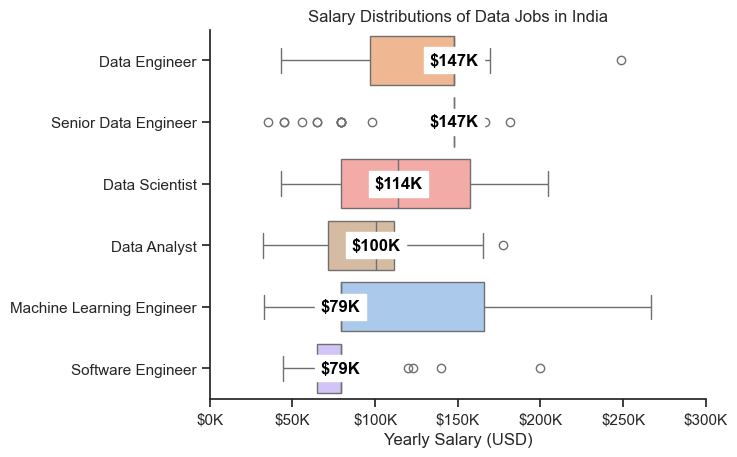

In [16]:
# Creating the boxplot for the salary distributions of the top 6 job titles in India

sns.set_theme(style='ticks')
ax = sns.boxplot(
    data=df_In_top6,
    x='salary_year_avg',    # X-axis: yearly salary
    y='job_title_short',    # Y-axis: job title
    order=job_order, 
    hue='job_title_short',  # Color by job title 
    palette="pastel",       # Palette for the colors
    legend=False
)
sns.despine()

# Title and labels
plt.title('Salary Distributions of Data Jobs in India')     # Set the title for the plot
plt.xlabel('Yearly Salary (USD)')                           # Set the label for the x-axis
plt.ylabel('')                                              # Set the label for the y-axis
plt.xlim(0, 300000)                                         # Set the x-axis limits from 0 to 300,000

# Format x-axis ticks
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')  # Format x-axis ticks to show salary in thousands
plt.gca().xaxis.set_major_formatter(ticks_x)                    # Set the formatter for the x-axis ticks

# Annotate medians
medians = df_In_top6.groupby("job_title_short")["salary_year_avg"].median() 
for idx, job in enumerate(job_order): 
    median_val = medians[job] 
    ax.text(
        median_val, idx,                    # position: median value on x, job index on y
        f'${int(median_val/1000)}K',        # label text
        ha='center', va='center',           # alignment
        fontweight='bold', color='black',   # font weight and color
        backgroundcolor='white'             # background color for better visibility
    )

plt.show()

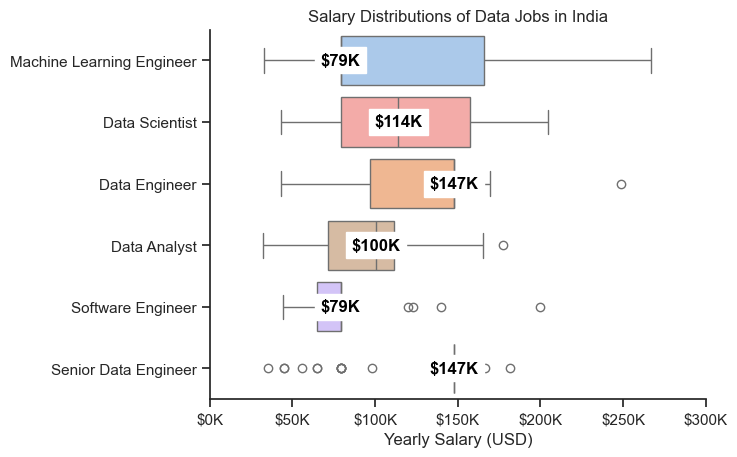

In [17]:
# Ordering the job titles manually for better visualization
job_order = [
    "Machine Learning Engineer",
    "Data Scientist",
    "Data Engineer",
    "Data Analyst",
    "Software Engineer",
    "Senior Data Engineer"
]

# Create the boxplot with the new order
sns.set_theme(style='ticks')
ax = sns.boxplot(
    data=df_In_top6,
    x='salary_year_avg',     # X-axis: yearly salary
    y='job_title_short',     # Y-axis: job title
    order=job_order,
    hue='job_title_short',  # Color by job title
    palette="pastel",       # Palette for the colors
    legend=False
)
sns.despine()

# Title and labels
plt.title('Salary Distributions of Data Jobs in India')     # Set the title for the plot
plt.xlabel('Yearly Salary (USD)')                           # Set the label for the x-axis
plt.ylabel('')                                              # Set the label for the y-axis
plt.xlim(0, 300000)                                         # Set the x-axis limits from 0 to 300,000

# Format x-axis ticks
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K') # Format x-axis ticks to show salary in thousands
plt.gca().xaxis.set_major_formatter(ticks_x)                   # Set the formatter for the x-axis ticks

# Annotate medians
medians = df_In_top6.groupby("job_title_short")["salary_year_avg"].median()
for idx, job in enumerate(job_order):
    median_val = medians[job]
    ax.text(
        median_val, idx,
        f'${int(median_val/1000)}K',        # Label text showing the median salary in thousands
        ha='center', va='center',           # Horizontal and vertical alignment of the text
        fontweight='bold', color='black',   # Font weight and color for the text
        backgroundcolor='white'             # Background color for the text
    )

plt.show()

In [18]:
# Filtering the DataFrame to include only rows where the 'job_title_short' is 'Data Analyst' and the 'job_country' is 'India'.
df_In = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_In = df_In.dropna(subset=['salary_year_avg'])

# Converting the 'job_skills' column to a list of skills
df_In = df_In.explode('job_skills')

df_In[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
11412,50400.0,python
11412,50400.0,sql
11412,50400.0,aws
11412,50400.0,azure
11412,50400.0,excel


For Top Paying Skills.

In [19]:
# Grouping the DataFrame by 'job_skills' and calculating the count and median of 'salary_year_avg', then sorting by median in descending order
df_DA_top_pay = df_In.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)

# Limiting the DataFrame to the top 10 skills based on median salary
df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_top_pay

,count,median
job_skills,,
pyspark,1,165000.0
linux,1,165000.0
gitlab,1,165000.0
mysql,1,165000.0
postgresql,1,165000.0
mongodb,6,163782.0
gdpr,2,163782.0
neo4j,1,163782.0
databricks,3,163782.0


For Most in-Demand Skills.

In [20]:
# Grouping the DataFrame by 'job_skills' and calculating the count and median of 'salary_year_avg', then sorting by count in descending order
df_DA_skills = df_In.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)

df_DA_skills

,count,median
job_skills,,
spark,11,111175.0
power bi,17,111175.0
tableau,20,108087.5
excel,39,98500.0
sql,46,96050.0
python,36,96050.0
azure,15,93600.0
r,18,79200.0
aws,12,79200.0


Creating a bar plot for the top 10 highest paid skills and the top 10 most in-demand skills for Data Analysts in India.

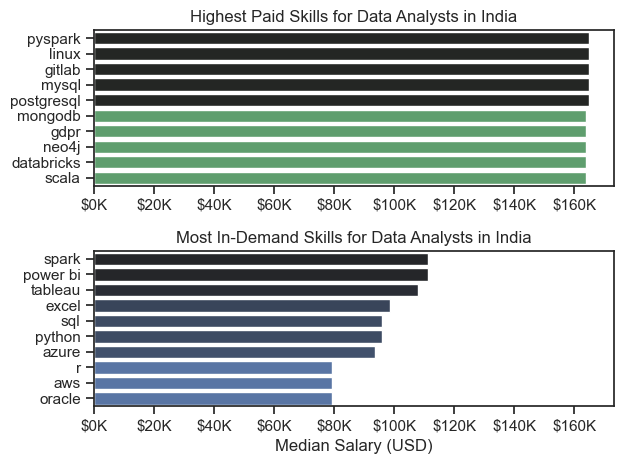

In [21]:
fig, ax = plt.subplots(2, 1) # Create a figure with two subplots
fig.subplots_adjust(hspace=0.4) # Adjust the space between the subplots

# Top 10 Highest Paid Skills for Data Analysts
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, hue='median', ax=ax[0], palette ='dark:g_r' )
ax[0].legend().remove()
ax[0].set_title('Highest Paid Skills for Data Analysts in India') # Set the title for the first subplot
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K')) # Format x-axis ticks

# Top 10 Most In-Demand Skills for Data Analysts')
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, hue='median', ax=ax[1], palette='dark:b_r')
ax[1].legend().remove()
ax[1].set_title('Most In-Demand Skills for Data Analysts in India') # Set the title for the second subplot
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)') 
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.set_theme(style='ticks') # Set the theme for the plots
plt.tight_layout() # Adjust the layout to prevent overlap
plt.show()

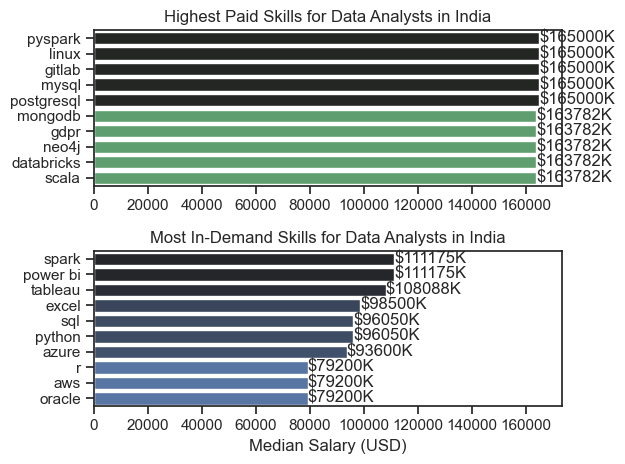

In [22]:
fig, ax = plt.subplots(2, 1)
fig.subplots_adjust(hspace=0.4)


# Top 10 Highest Paid Skills for Data Analysts
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, hue='median', ax=ax[0], palette ='dark:g_r' )
ax[0].legend().remove()
ax[0].set_title('Highest Paid Skills for Data Analysts in India')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='${:.0f}K') # Add labels to the bars



# Top 10 Most In-Demand Skills for Data Analysts')
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, hue='median', ax=ax[1], palette='dark:b_r')
ax[1].legend().remove()
ax[1].set_title('Most In-Demand Skills for Data Analysts in India')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
for container in ax[1].containers:
    ax[1].bar_label(container, fmt='${:.0f}K') # Add labels to the bars


sns.set_theme(style='ticks') 
plt.tight_layout()
plt.show()